In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Visualization settings
sns.set(style="whitegrid")


In [7]:
columns = [
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width",
    "species"
]

df = pd.read_csv("data/iris.data", header=None, names=columns)

df.head()


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [8]:
print("Shape:", df.shape)
print("\nClass distribution:\n")
print(df['species'].value_counts())


Shape: (150, 5)

Class distribution:

species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


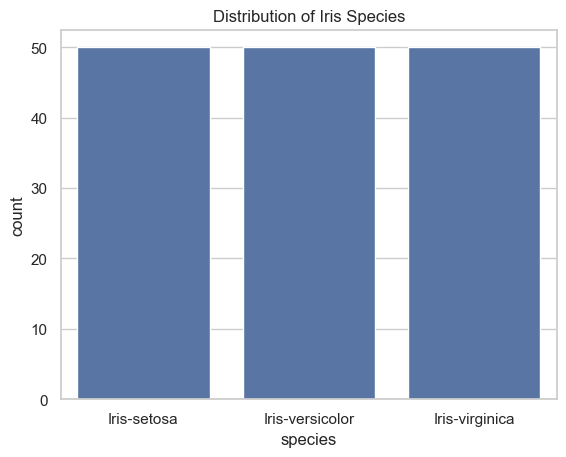

In [9]:
plt.figure()
sns.countplot(x="species", data=df)
plt.title("Distribution of Iris Species")
plt.show()


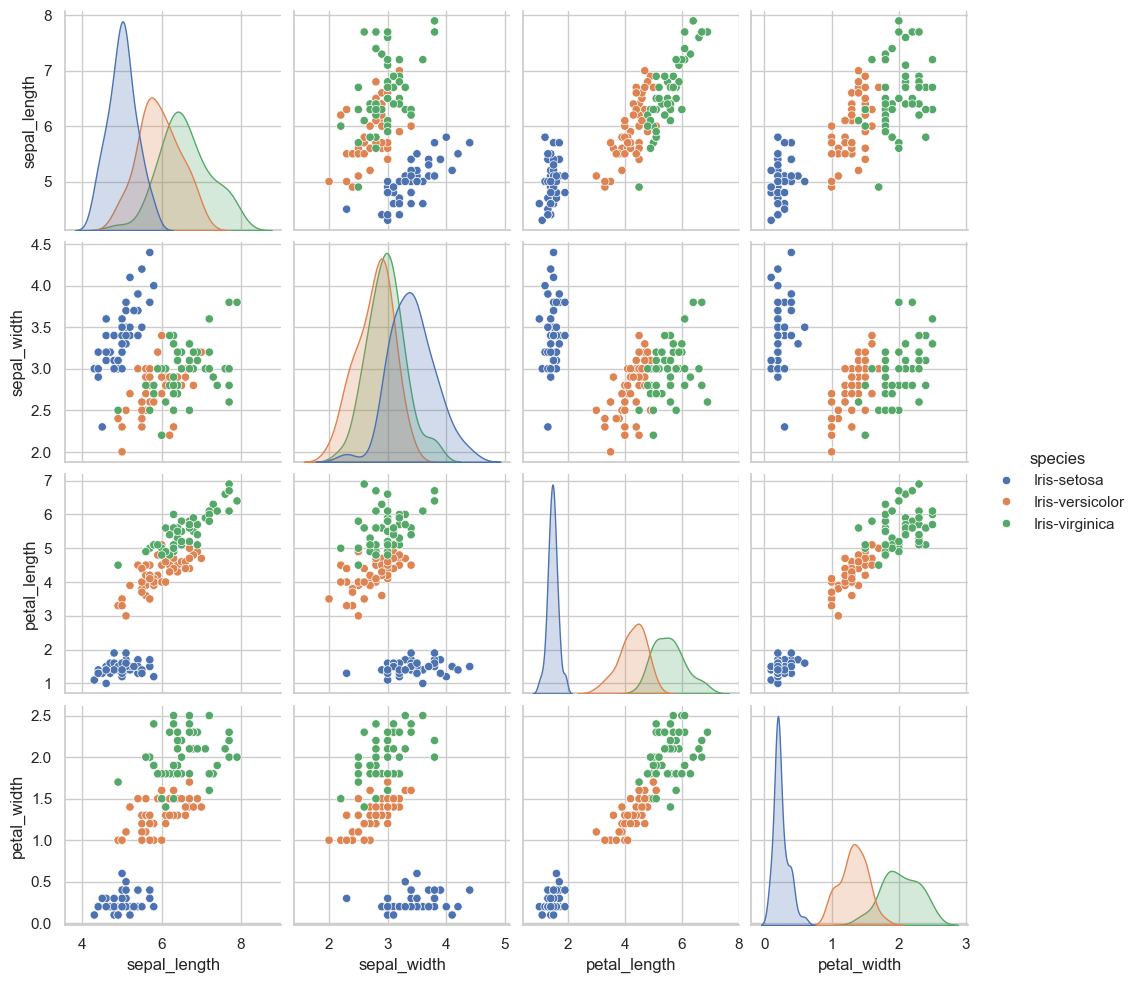

In [10]:
sns.pairplot(df, hue="species")
plt.show()


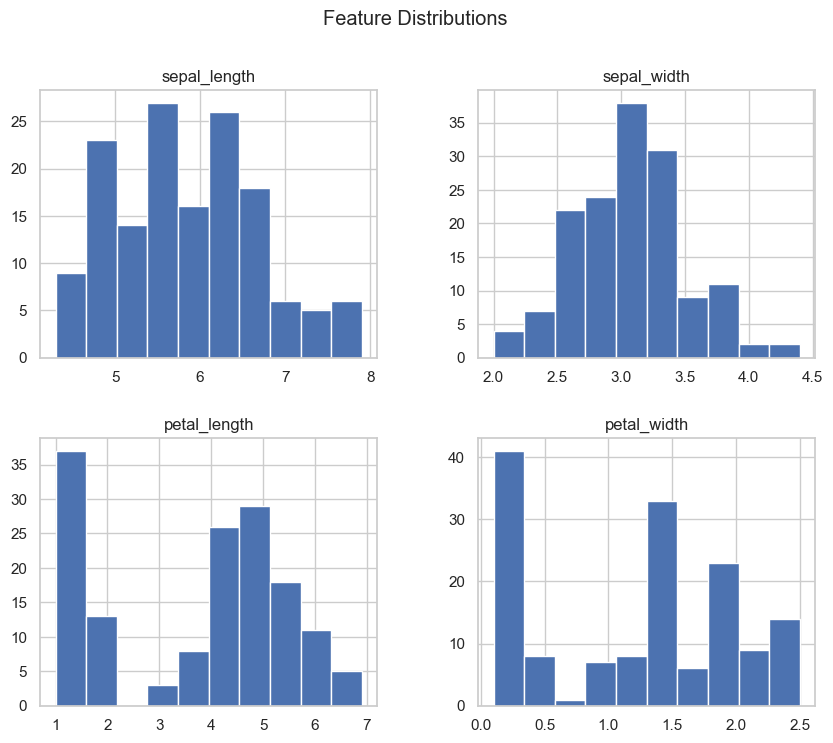

In [11]:
df.hist(figsize=(10, 8))
plt.suptitle("Feature Distributions")
plt.show()


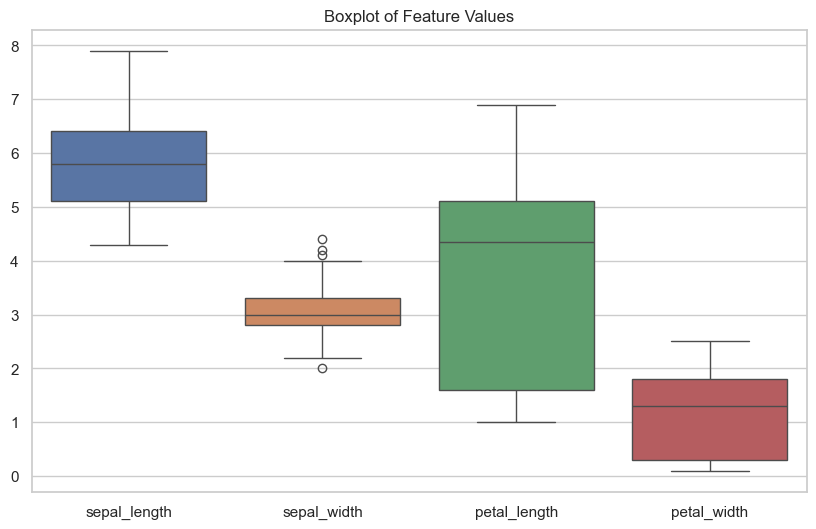

In [12]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df.drop(columns="species"))
plt.title("Boxplot of Feature Values")
plt.show()


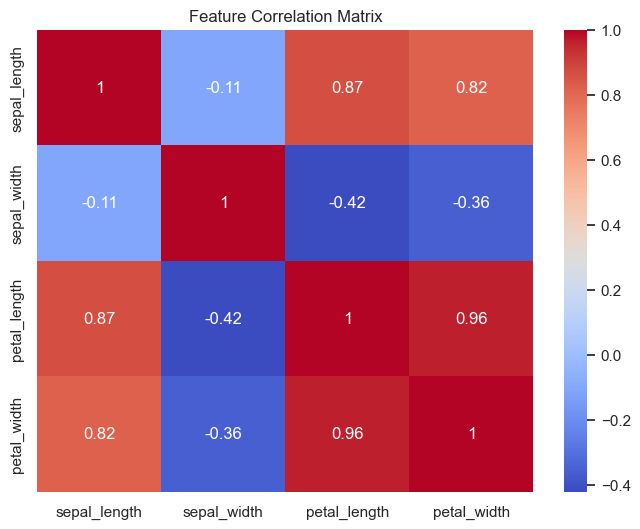

In [13]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.drop(columns="species").corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()


## EDA Summary

- The dataset is balanced with no class imbalance.
- Petal length and petal width are the most informative features.
- Iris-setosa is clearly separable from other classes.
- Minimal outliers are present and do not impact modeling.
- Feature correlations suggest strong relationships among petal measurements.


#Data Preprocessing

In [14]:
X = df.drop(columns="species")
y = df["species"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)


Features shape: (150, 4)
Target shape: (150,)


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)


Training set: (120, 4)
Testing set: (30, 4)


In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## Data Preprocessing Summary

- Split dataset into training and testing sets (80–20).
- Maintained class balance using stratification.
- Applied standard scaling to normalize feature values.


#Model Building & Evaluation

In [17]:
#Model 1: Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

log_reg = LogisticRegression(max_iter=200)
log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))


Logistic Regression Accuracy: 0.9333333333333333

Classification Report:
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30



In [18]:
#Model 2: K-Nearest Neighbors (KNN)

from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))

KNN Accuracy: 0.9333333333333333


In [19]:
#Model 3: Decision Tree

from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.9333333333333333


In [20]:
#Compare Model Performance

model_results = pd.DataFrame({
    "Model": ["Logistic Regression", "KNN", "Decision Tree"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_dt)
    ]
})

model_results

,Model,Accuracy
0,Logistic Regression,0.933333
1,KNN,0.933333
2,Decision Tree,0.933333


Confusion Matrix – Logistic Regression

In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


In [22]:
cm = confusion_matrix(y_test, y_pred_lr)
cm


array([[10,  0,  0],
       [ 0,  9,  1],
       [ 0,  1,  9]])

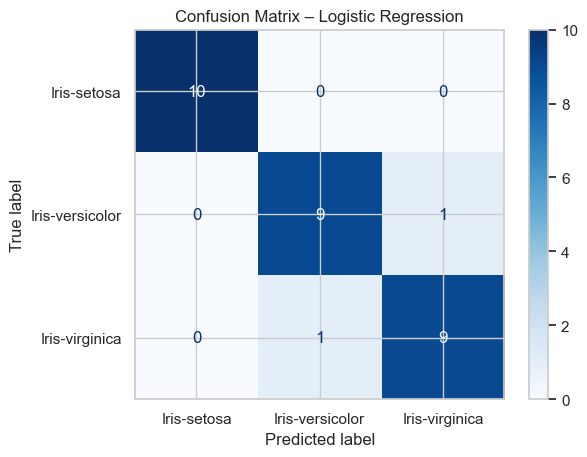

In [23]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=log_reg.classes_
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix – Logistic Regression")
plt.show()


# Advanced Evaluation
## Cross-Validation


In [24]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    log_reg,
    X_train_scaled,
    y_train,
    cv=5
)

print("Cross-validation scores:", cv_scores)
print("Mean CV accuracy:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())


Cross-validation scores: [0.91666667 0.95833333 0.95833333 0.95833333 1.        ]
Mean CV accuracy: 0.9583333333333334
Standard Deviation: 0.026352313834736508


## Hyperparameter Tuning using GridSearchCV


In [25]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "C": [0.01, 0.1, 1, 10, 100]
}

grid = GridSearchCV(
    LogisticRegression(max_iter=200),
    param_grid,
    cv=5
)

grid.fit(X_train_scaled, y_train)

print("Best parameter:", grid.best_params_)
print("Best CV score:", grid.best_score_)


Best parameter: {'C': 10}
Best CV score: 0.9666666666666668


In [26]:
best_model = grid.best_estimator_


## Feature Importance (Logistic Regression Coefficients)


In [27]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": best_model.coef_[0]
}).sort_values(by="Coefficient", ascending=False)

feature_importance


,Feature,Coefficient
1,sepal_width,1.713210
0,sepal_length,-1.804435
3,petal_width,-3.195644
2,petal_length,-3.307377


In [28]:
import joblib

joblib.dump(scaler, "scaler.joblib")
joblib.dump(best_model, "logistic_regression_best_model.joblib")


['logistic_regression_best_model.joblib']